# 04 — LLM-as-Policy: Multi-Provider Comparison

**Environment:** CityLearn 2022 challenge dataset, 6 buildings, battery-only, `EcoPeakBatteryReward`.

**Question:** How do mid-cost LLMs from different vendors compare as zero-shot battery controllers on a 1-week window?

**Models compared (all mid-cost / non-flagship):**

| Provider  | Model                  | Approx. cost (per 1M in / 1M out)  |
|-----------|------------------------|------------------------------------|
| Anthropic | `claude-haiku-4-5`     | $1 / $5                            |
| DeepSeek  | `deepseek-chat` (V3)   | $0.27 / $1.10                      |
| Kimi      | `moonshot-v1-8k`       | $0.20 / $2                         |

**Reference policies:** No-op, Random, RBC (price + solar aware).

**API keys:** Loaded from `.env` at the project root (`KIMI_API_KEY`, `ANTHROPIC_API_KEY`, `DEEPSEEK_API_KEY`).
VS Code: `python.terminal.useEnvFile = true` in `.vscode/settings.json` for terminal injection.

## 0. Config — change all experiment parameters here

In [25]:
import os
from pathlib import Path

# ── Load .env from project root ──────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv(Path("../.env"))   # picks up KIMI_API_KEY / ANTHROPIC_API_KEY / DEEPSEEK_API_KEY

# ── Provider list (mid-cost models only) ─────────────────────────────────
# Each provider has: name, model, env_var with API key, base_url (None = default).
# Comment out / add entries here to change which providers run.
PROVIDERS: list[dict] = [
    {
        "name":     "deepseek",
        "model":    "deepseek-chat",                       # V3 chat (not V3.1 reasoner)
        "key_env":  "DEEPSEEK_API_KEY",
        "base_url": "https://api.deepseek.com/v1",
    },
    {
        "name":     "kimi",
        "model":    "kimi-k2.5",                      # alt: kimi-k2-turbo-preview (more $)
        "key_env":  "KIMI_API_KEY",
        "base_url": "https://api.moonshot.ai/v1",          # international endpoint
    },
]

# ── Experiment window ────────────────────────────────────────────────────
SEED: int = 42
WEEK_START: int = 3624       # mid-December, Wed 24:00 (CityLearn hour=1..24)
WEEK_LEN: int   = 168        # one week of hourly steps

BUILDINGS: list = [0, 1, 2, 3, 4, 5]

ACTIVE_OBSERVATIONS: list = [
    "month", "hour", "day_type",
    "electrical_storage_soc",
    "net_electricity_consumption",
    "non_shiftable_load",
    "solar_generation",
    "electricity_pricing",
    "carbon_intensity",
]

# ── Binning thresholds ───────────────────────────────────────────────────
PRICE_PEAK_THRESHOLD: float = 0.40    # 2022 dataset is binary 0.21 / 0.50
CARBON_MID_THRESHOLD:  float = 0.14
CARBON_HIGH_THRESHOLD: float = 0.17
CARBON_PEAK_THRESHOLD: float = 0.19
SOLAR_LOW_THRESHOLD:  float = 0.05
SOLAR_HIGH_THRESHOLD: float = 1.50

# ── Reward weights ───────────────────────────────────────────────────────
W_COST:   float = 0.4
W_CARBON: float = 0.4
W_PEAK:   float = 0.2

# ── Dataset path ─────────────────────────────────────────────────────────
DATASET_ROOT = Path("../data/citylearn_datasets/citylearn_challenge_2022_phase_all")

# ── Sanity print ─────────────────────────────────────────────────────────
print("Config loaded.")
print(f"  window = t{WEEK_START}..{WEEK_START + WEEK_LEN - 1} ({WEEK_LEN} steps)")
print(f"  providers ({len(PROVIDERS)}):")
for p in PROVIDERS:
    has_key = bool(os.environ.get(p["key_env"], "").strip())
    flag = "✓" if has_key else "✗ MISSING"
    print(f"    [{flag}] {p['name']:10s} model={p['model']:25s} env={p['key_env']}")

Config loaded.
  window = t3624..3791 (168 steps)
  providers (2):
    [✓] deepseek   model=deepseek-chat             env=DEEPSEEK_API_KEY
    [✓] kimi       model=kimi-k2.5                 env=KIMI_API_KEY


In [2]:
import json
import re
import time
import random
import warnings
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import citylearn
from citylearn.citylearn import CityLearnEnv
from citylearn.reward_function import RewardFunction

from openai    import OpenAI            # works for any OpenAI-compatible API (Kimi, DeepSeek)
from anthropic import Anthropic

warnings.filterwarnings("ignore")
np.random.seed(SEED)
random.seed(SEED)

print(f"CityLearn {citylearn.__version__}")

CityLearn 2.5.0


## 1. Environment

`snapshot_state(env)` bypasses the CityLearn v2.5 observation-vector bug:
`electrical_storage_soc` and `net_electricity_consumption` in the raw obs vector are stale. We read directly from building objects instead.

In [3]:
SCHEMA_FILE = DATASET_ROOT / "schema.json"


def load_schema() -> dict:
    with open(SCHEMA_FILE) as f:
        schema = json.load(f)
    schema["root_directory"] = str(DATASET_ROOT.resolve())
    return schema


class EcoPeakBatteryReward(RewardFunction):
    """Weighted cost + carbon + peak-shaving reward."""

    def __init__(
        self,
        env_metadata: dict[str, Any],
        w_cost: float = W_COST,
        w_carbon: float = W_CARBON,
        w_peak: float = W_PEAK,
    ):
        super().__init__(env_metadata)
        self.w_cost = w_cost
        self.w_carbon = w_carbon
        self.w_peak = w_peak

    def calculate(self, observations: list[dict]) -> list[float]:
        rewards = []
        for o in observations:
            eco_price = (
                self.w_cost   * o.get("electricity_pricing",   0.0)
                + self.w_carbon * o.get("carbon_intensity",   0.0)
            )
            cost = o.get("net_electricity_consumption", 0.0) * eco_price
            soc  = o.get("electrical_storage_soc", 0.0)
            base_penalty = -(1.0 + np.sign(cost) * soc) * abs(cost)
            peak_penalty = -(o.get("net_electricity_consumption", 0.0) ** 2) * self.w_peak
            rewards.append(float(base_penalty + peak_penalty))
        if self.central_agent:
            return [float(sum(rewards))]
        return rewards


def make_env(start: int = WEEK_START, length: int = WEEK_LEN) -> CityLearnEnv:
    env = CityLearnEnv(
        schema=load_schema(),
        buildings=BUILDINGS,
        central_agent=False,
        active_actions=["electrical_storage"],
        active_observations=ACTIVE_OBSERVATIONS,
        random_seed=SEED,
        simulation_start_time_step=start,
        simulation_end_time_step=start + length - 1,
    )
    env.reward_function = EcoPeakBatteryReward(env.get_metadata())
    return env


def snapshot_state(env: CityLearnEnv) -> list[dict]:
    """Read the current district state directly from building objects."""
    t = env.time_step
    out = []
    for b in env.buildings:
        out.append({
            "month":    int(b.energy_simulation.month[t]),
            "day_type": int(b.energy_simulation.day_type[t]),
            "hour":     int(b.energy_simulation.hour[t]),
            "electricity_pricing":  float(b.pricing.electricity_pricing[t]),
            "carbon_intensity":     float(b.carbon_intensity.carbon_intensity[t]),
            "solar_generation":     float(b.energy_simulation.solar_generation[t]),
            "non_shiftable_load":   float(b.non_shiftable_load[t]),
            "electrical_storage_soc":           float(b.electrical_storage.soc[t - 1]) if t > 0 else 0.0,
            "net_electricity_consumption_last": float(b.net_electricity_consumption[t - 1]) if t > 0 else 0.0,
        })
    return out


# ── Sanity check ─────────────────────────────────────────────────────────
_env = make_env()
_obs, _ = _env.reset()
print(f"buildings: {len(_obs)}  |  obs dim/building: {len(_obs[0])}")
print(f"episode length: {_env.time_steps} steps")
_snap = snapshot_state(_env)
print(f"\nsnapshot at t=0, B0: {_snap[0]}")

buildings: 6  |  obs dim/building: 9
episode length: 168 steps

snapshot at t=0, B0: {'month': 12, 'day_type': 4, 'hour': 24, 'electricity_pricing': 0.20999999344348907, 'carbon_intensity': 0.2018524408340454, 'solar_generation': 0.0, 'non_shiftable_load': 0.6017666459083557, 'electrical_storage_soc': 0.0, 'net_electricity_consumption_last': 0.0}


## 2. State Renderer

Continuous values are bucketed (LOW / PEAK, NONE / LOW / HIGH, etc.) before being sent to the LLM — categorical reasoning is more reliable than numeric reasoning.

In [8]:
DAY_NAMES = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat", 8: "Hol"}


def price_bucket(v: float) -> str:
    return "PEAK" if float(v) >= PRICE_PEAK_THRESHOLD else "LOW"


def carbon_bucket(v: float) -> str:
    x = float(v)
    if x >= CARBON_PEAK_THRESHOLD: return "PEAK"
    if x >= CARBON_HIGH_THRESHOLD: return "HIGH"
    if x >= CARBON_MID_THRESHOLD:  return "MID"
    return "LOW"


def solar_bucket(v: float) -> str:
    x = float(v)
    if x >= SOLAR_HIGH_THRESHOLD: return "HIGH"
    if x >= SOLAR_LOW_THRESHOLD:  return "LOW"
    return "NONE"


def render_state(snap: list[dict]) -> str:
    d0 = snap[0]
    hour, day, month = d0["hour"], DAY_NAMES.get(d0["day_type"], "?"), d0["month"]
    price, carbon = d0["electricity_pricing"], d0["carbon_intensity"]


    header = (
        f"Month {month}, {day} {hour:02d}:00  |  "
        f"price={price:.3f} ({price_bucket(price)})  |  "
        f"carbon={carbon:.3f} ({carbon_bucket(carbon)})  |  "
    )
    lines = [header, "Buildings:"]
    for i, d in enumerate(snap):
        lines.append(
            f"  B{i}: SoC={d['electrical_storage_soc'] * 100:5.1f}%  "
            f"load={d['non_shiftable_load']:.2f} kWh  "
            f"last_net={d['net_electricity_consumption_last']:+.2f} kWh  "
            f"solar={solar_bucket(d['solar_generation'])}"
        )
    return "\n".join(lines)


# Sanity print of the prompt the LLM will see at t=0
print(render_state(_snap))

Month 12, Wed 24:00  |  price=0.210 (LOW)  |  carbon=0.202 (PEAK)  |  
Buildings:
  B0: SoC=  0.0%  load=0.60 kWh  last_net=+0.00 kWh  solar=NONE
  B1: SoC=  0.0%  load=1.68 kWh  last_net=+0.00 kWh  solar=NONE
  B2: SoC=  0.0%  load=0.28 kWh  last_net=+0.00 kWh  solar=NONE
  B3: SoC=  0.0%  load=0.45 kWh  last_net=+0.00 kWh  solar=NONE
  B4: SoC=  0.0%  load=1.03 kWh  last_net=+0.00 kWh  solar=NONE
  B5: SoC=  0.0%  load=1.59 kWh  last_net=+0.00 kWh  solar=NONE


## 3. LLM Interface

### Multi-provider abstraction

Each provider gets wrapped in an `LLMProvider` instance with a uniform `complete(system, user) -> str` method. Internally:

- **Anthropic** uses `anthropic.Anthropic().messages.create(...)`
- **DeepSeek**, **Kimi/Moonshot** use the OpenAI client pointed at their compatible endpoints (`base_url`)

### Battery dynamics in the system prompt

| Direction | Physics | Action guidance |
|-----------|---------|----------------|
| Charge (+) | Unconstrained — `+1.0` fills ~70% SoC, ~5 kWh from grid | Use **small** values (+0.1 to +0.3); avoid synchronised spikes |
| Discharge (−) | Hardware-capped at ~1.5 kWh/h | `-1.0` is **safe** — no large export spike |

In [15]:
SYSTEM_PROMPT = """You are a battery controller for 6 buildings in a CityLearn district.
Goal: minimise electricity cost, carbon emissions, AND district peak load.

STATE VARIABLES:
- hour: 1..24 (CityLearn convention; 1..6=night, 7..18=day, 19..24=evening)
- price: LOW (0.21 $/kWh) or PEAK (0.50 $/kWh)
- carbon: LOW / MID / HIGH / PEAK (grid carbon intensity)
- solar: NONE / LOW / HIGH (building-level PV output)
- SoC: battery state of charge, 0..1 (fraction of capacity)
- load: fixed building demand this hour (kWh)

BATTERY PHYSICS (critical for good actions):
- Charging is UNCONSTRAINED: action +1.0 fills ~70% SoC in one step, pulling ~5 kWh from the
  grid per building. Charging 6 buildings at +1.0 simultaneously creates a ~30 kWh demand spike
  that severely penalises the daily_peak KPI. Use SMALL charge actions (+0.1 to +0.3).
- Discharging is HARDWARE-CAPPED at ~1.5 kWh/h regardless of magnitude. Action -1.0 is safe
  and simply discharges as fast as the hardware allows.

STRATEGY RULES:
1. price=LOW:  prefer charging (small magnitude, +0.1 to +0.3)
2. price=PEAK: prefer discharging (−1.0 is safe; use it for buildings with SoC > 20%)
3. solar=HIGH: add a small charge to capture free PV before export (even if price=PEAK)
4. Never charge a building with SoC >= 90%; never discharge one with SoC <= 10%


REASONING PROTOCOL — think step by step before outputting actions:
Step 1: Note price regime, carbon level, and solar availability.
Step 2: For each building, note SoC headroom (charge_room = 1 − SoC, discharge_room = SoC)..
Step 3: Decide per-building actions achieving price/carbon arbitrage WITHOUT synchronised spikes.
Step 4: Output exactly 6 action lines.

OUTPUT FORMAT (strict — nothing after the last </action> tag):
<action building=0>VALUE</action>
<action building=1>VALUE</action>
<action building=2>VALUE</action>
<action building=3>VALUE</action>
<action building=4>VALUE</action>
<action building=5>VALUE</action>
"""

In [20]:
ACTION_RE = re.compile(r"<action building=(\d)>\s*(-?\d*\.?\d+)\s*</action>")


class LLMProvider:
    """Uniform wrapper over Anthropic / OpenAI-compatible chat APIs."""

    def __init__(self, name: str, model: str, key_env: str, base_url: str | None = None):
        self.name  = name
        self.model = model
        self.label = f"{name}:{model}"

        api_key = os.environ.get(key_env, "").strip()
        if not api_key:
            raise RuntimeError(f"Missing API key in env var {key_env}")

        if name == "anthropic":
            self.client = Anthropic(api_key=api_key)
            self.kind   = "anthropic"
        else:
            # OpenAI-compatible (DeepSeek, Kimi/Moonshot, OpenAI itself)
            self.client = OpenAI(api_key=api_key, base_url=base_url)
            self.kind   = "openai_compat"

    def complete(self, system: str, user: str, max_tokens: int = 2000) -> str:
        if self.kind == "anthropic":
            resp = self.client.messages.create(
                model=self.model,
                system=system,
                messages=[{"role": "user", "content": user}],
                max_tokens=max_tokens,
                temperature=0.0,
            )
            return "".join(b.text for b in resp.content if getattr(b, "type", None) == "text")

        # OpenAI-compatible path
        kwargs: dict = dict(
            model=self.model,
            messages=[
                {"role": "system", "content": system},
                {"role": "user",   "content": user},
            ],
        )
        if not self.model.startswith(("o1", "o3")):     # reasoning models reject temperature
            kwargs["temperature"] = 1
        resp = self.client.chat.completions.create(**kwargs)
        return resp.choices[0].message.content


def parse_actions(raw: str, n_buildings: int = 6) -> list[float]:
    by_id: dict[int, float] = {}
    for bid, val in ACTION_RE.findall(raw):
        by_id[int(bid)] = float(val)
    return [float(np.clip(by_id.get(i, 0.0), -1.0, 1.0)) for i in range(n_buildings)]


def llm_step(
    provider: LLMProvider,
    state_text: str,
    max_retries: int = 3,
) -> tuple[list[float], str, bool]:
    """Query the provider and parse actions. Returns (actions, raw, used_fallback)."""
    last_raw = ""
    for attempt in range(max_retries):
        try:
            last_raw = provider.complete(SYSTEM_PROMPT, f"STATE:\n{state_text}")
            if ACTION_RE.search(last_raw):
                return parse_actions(last_raw), last_raw, False
        except Exception as exc:
            last_raw = f"ERROR (attempt {attempt + 1}): {exc}"
            if attempt < max_retries - 1:
                time.sleep(1.0)
    return [0.0] * 6, last_raw, True


# ── Quick smoke test on each configured provider ─────────────────────────
PROVIDER_OBJS: dict[str, LLMProvider] = {}
for spec in PROVIDERS:
    try:
        p = LLMProvider(**spec)
        PROVIDER_OBJS[spec["name"]] = p
        # one tiny sanity call
        out = p.complete("You answer in one word.", "Say PONG.")
        print(f"  [✓] {p.label:35s} -> {out.strip()[:40]!r}")
    except Exception as exc:
        print(f"  [✗] {spec['name']:10s} {spec['model']:25s} skipped: {exc}")

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 401 Unauthorized"


  [✗] anthropic  claude-haiku-4-5          skipped: Error code: 401 - {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'invalid x-api-key'}, 'request_id': 'req_011CaaKo9WFBS886Drmdf6PH'}


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] deepseek:deepseek-chat              -> 'PONG'


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] kimi:kimi-k2.5                      -> 'PONG'


## 4. Rollout Framework

In [21]:
def run_policy(
    name: str,
    policy_fn,
    start: int = WEEK_START,
    length: int = WEEK_LEN,
) -> tuple[pd.DataFrame, CityLearnEnv, list[dict]]:
    """Run a policy for one episode. Returns (df, env, raw_log).

    policy_fn signature: (snap, t) -> list[float]  OR  (list[float], raw, fallback).
    """
    env = make_env(start=start, length=length)
    env.reset()

    rows: list[dict] = []
    raw_log: list[dict] = []
    done = False
    t = 0
    t0 = time.time()

    while not done:
        snap = snapshot_state(env)
        result = policy_fn(snap, t)

        if isinstance(result, tuple):
            acts, raw, fb = result
            raw_log.append({
                "t": t,
                "state_text": render_state(snap),
                "raw": raw,
                "fallback": bool(fb),
            })
        else:
            acts = result

        action_input = [[float(a)] for a in acts]
        _obs, reward, terminated, truncated, _info = env.step(action_input)
        done = bool(terminated or truncated)

        post = snapshot_state(env)
        rows.append({
            "policy": name, "t": t,
            "price": snap[0]["electricity_pricing"],
            "reward_sum": float(np.sum(reward)),
            **{f"a{i}":   acts[i]                                      for i in range(6)},
            **{f"r{i}":   float(reward[i])                             for i in range(6)},
            **{f"soc{i}": post[i]["electrical_storage_soc"]            for i in range(6)},
            **{f"net{i}": post[i]["net_electricity_consumption_last"] for i in range(6)},
        })
        t += 1

    df = pd.DataFrame(rows)
    elapsed = time.time() - t0
    n_fb = sum(1 for r in raw_log if r["fallback"])
    fb_msg = f" | fallbacks={n_fb}/{len(raw_log)}" if raw_log else ""
    print(f"[{name}] {t} steps in {elapsed:.1f}s | total_reward={df['reward_sum'].sum():.2f}{fb_msg}")
    return df, env, raw_log

## 5. Reference Policies (no-LLM)

In [22]:
def policy_noop(snap: list[dict], t: int) -> list[float]:
    return [0.0] * 6


_rng = np.random.default_rng(SEED)

def policy_random(snap: list[dict], t: int) -> list[float]:
    return _rng.uniform(-1.0, 1.0, size=6).tolist()


def policy_rbc(snap: list[dict], t: int) -> list[float]:
    """Price + solar aware RBC. Uses the battery asymmetry insight."""
    acts = []
    for d in snap:
        soc = d["electrical_storage_soc"]
        prc = d["electricity_pricing"]
        sol = d["solar_generation"]
        if solar_bucket(sol) == "HIGH" and soc < 0.85:
            acts.append(0.2)            # capture free solar
        elif price_bucket(prc) == "PEAK" and soc > 0.10:
            acts.append(-1.0)           # discharge during peak — hardware-capped, safe
        elif price_bucket(prc) == "LOW" and soc < 0.90:
            acts.append(0.25)           # trickle-charge during off-peak
        else:
            acts.append(0.0)
    return acts


def make_policy_llm(provider: LLMProvider, verbose: bool = True):
    """Bind a provider into a policy function with the standard signature."""
    def _policy(snap, t):
        text = render_state(snap)
        acts, raw, fb = llm_step(provider, text)
        if verbose:
            soc_str = ",".join(f"{d['electrical_storage_soc'] * 100:.0f}" for d in snap)
            flag = " [FALLBACK]" if fb else ""
            print(
                f"  [{provider.name:9s}] t={t:3d} price={snap[0]['electricity_pricing']:.2f} "
                f"soc%=[{soc_str}] -> {[f'{a:+.2f}' for a in acts]}{flag}"
            )
        return acts, raw, fb
    return _policy


print("Reference policies defined: noop, random, rbc.  LLM policies built per-provider.")

Reference policies defined: noop, random, rbc.  LLM policies built per-provider.


## 6. Run Reference Baselines

In [23]:
df_noop,   env_noop,   _ = run_policy("noop",   policy_noop)
df_random, env_random, _ = run_policy("random", policy_random)
df_rbc,    env_rbc,    _ = run_policy("rbc",    policy_rbc)

[noop] 167 steps in 0.4s | total_reward=-729.39
[random] 167 steps in 0.4s | total_reward=-1959.94
[rbc] 167 steps in 0.4s | total_reward=-1166.11


## 7. Run Each LLM Provider

> **Observability note:** `central_agent=False` (decentralised action interface), but the controller is **centrally coordinated** — one prompt covers all 6 buildings, one response returns 6 actions.
>
> **Cost estimate:** 168 calls × 3 providers ≈ **$0.50–$1.50 total** (Haiku 4.5 dominates the bill; DeepSeek and Kimi are <$0.20 each).

In [26]:
# Holds results for each provider that ran successfully
llm_runs: dict[str, dict] = {}

for spec in PROVIDERS:
    name = spec["name"]
    if name not in PROVIDER_OBJS:
        print(f"  skipping {name} (no client — see § 3 smoke test)")
        continue

    provider = PROVIDER_OBJS[name]
    print(f"\n=== Running {provider.label} ===")
    t0 = time.time()
    df, env, raw_log = run_policy(
        f"llm_{name}",
        make_policy_llm(provider, verbose=True),
    )
    print(f"({time.time() - t0:.0f}s wall clock)")
    llm_runs[name] = {
        "label":   provider.label,
        "df":      df,
        "env":     env,
        "raw_log": raw_log,
    }

print(f"\nFinished: {list(llm_runs.keys())}")


=== Running deepseek:deepseek-chat ===


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  [deepseek ] t=  0 price=0.21 soc%=[0,0,0,0,0,0] -> ['+0.20', '+0.20', '+0.25', '+0.20', '+0.25', '+0.20']


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  [deepseek ] t=  1 price=0.21 soc%=[14,14,18,14,18,14] -> ['+0.15', '+0.00', '+0.15', '+0.00', '+0.15', '+0.00']


...

INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  [kimi     ] t=  9 price=0.21 soc%=[92,92,91,92,92,92] -> ['+0.00', '+0.00', '+0.00', '+0.00', '+0.00', '+0.00']


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  [kimi     ] t= 10 price=0.21 soc%=[92,92,91,92,92,92] -> ['+0.00', '+0.00', '+0.00', '+0.00', '+0.00', '+0.00']


KeyboardInterrupt: 

## 8. Results

In [27]:
def summarize(df: pd.DataFrame) -> dict:
    net_cols = [f"net{i}" for i in range(6)]
    dist_net = df[net_cols].sum(axis=1)
    return {
        "policy":        df["policy"].iloc[0],
        "total_reward":  float(df["reward_sum"].sum()),
        "total_cost":    float((dist_net * df["price"]).sum()),
        "peak_net_kW":   float(dist_net.max()),
        "total_net_kWh": float(df[net_cols].values.sum()),
    }


rows = [summarize(df_noop), summarize(df_random), summarize(df_rbc)]
rows += [summarize(r["df"]) for r in llm_runs.values()]
summary = pd.DataFrame(rows).set_index("policy")
display(summary.round(3))

,total_reward,total_cost,peak_net_kW,total_net_kWh
policy,,,,
noop,-729.393,349.917,16.932,1212.267
random,-1959.937,387.404,43.043,1353.611
rbc,-1166.108,294.986,31.932,1277.553
llm_deepseek,-1222.935,311.600,29.932,1296.287


In [28]:
HEADLINE_KPIS = [
    "electricity_consumption_total",
    "cost_total",
    "carbon_emissions_total",
    "daily_peak_average",
    "ramping_average",
    "daily_one_minus_load_factor_average",
]


def district_kpis(env_obj: CityLearnEnv) -> pd.Series:
    df = env_obj.evaluate()
    if "level" in df.columns:
        mask = df["level"].astype(str).str.lower() == "district"
    elif "name" in df.columns:
        mask = df["name"].astype(str).str.lower() == "district"
    else:
        mask = pd.Series(True, index=df.index)
    d = df[mask]
    if d.empty:
        d = df.groupby("cost_function", as_index=False)["value"].mean()
    return d.set_index("cost_function")["value"].astype(float)


kpi_columns = {
    "No Control (noop)": district_kpis(env_noop),
    "Random":            district_kpis(env_random),
    "RBC":               district_kpis(env_rbc),
}
for name, run in llm_runs.items():
    kpi_columns[run["label"]] = district_kpis(run["env"])

kpi_table = pd.DataFrame(kpi_columns).sort_index().round(4)
present = [k for k in HEADLINE_KPIS if k in kpi_table.index]
print("District KPIs — lower is better; No Control column should be ≈ 1.000")
display(kpi_table.loc[present] if present else kpi_table)

District KPIs — lower is better; No Control column should be ≈ 1.000


,No Control (noop),Random,RBC,deepseek:deepseek-chat
cost_function,,,,
electricity_consumption_total,1.0000,1.5959,1.2516,1.3333
cost_total,1.0000,1.5410,1.0931,1.1772
carbon_emissions_total,1.0000,1.5970,1.2319,1.3174
daily_peak_average,1.0000,1.5396,1.5025,1.3471
ramping_average,1.0000,3.9603,2.2313,3.5059
daily_one_minus_load_factor_average,0.9913,1.2305,1.3112,1.2007


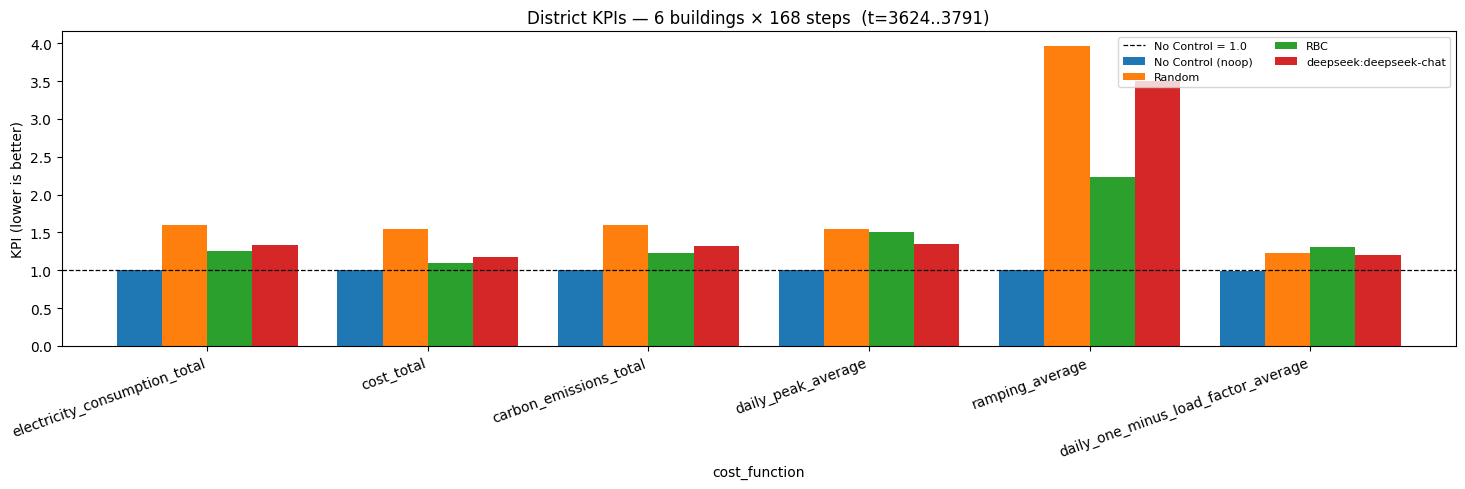

In [29]:
if present:
    ax = kpi_table.loc[present].plot(kind="bar", figsize=(15, 5), width=0.82)
    ax.axhline(1.0, color="k", ls="--", lw=0.9, label="No Control = 1.0")
    ax.set_ylabel("KPI (lower is better)")
    ax.set_title(
        f"District KPIs — 6 buildings × {WEEK_LEN} steps  "
        f"(t={WEEK_START}..{WEEK_START + WEEK_LEN - 1})"
    )
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

## 9. Diagnostics — Per Provider

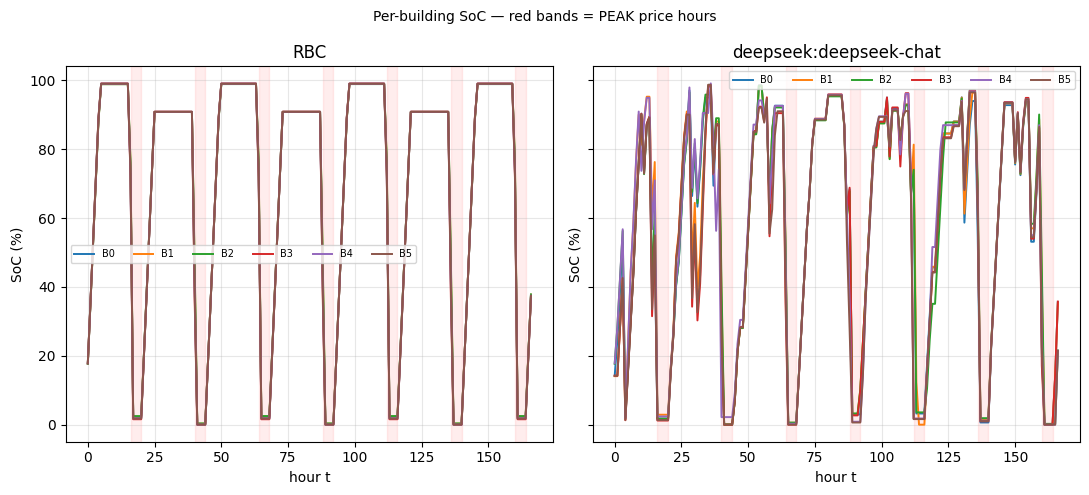

In [30]:
# 9.1 SoC trajectories — RBC + each LLM, side by side
panels = [(df_rbc, "RBC")]
for name, run in llm_runs.items():
    panels.append((run["df"], run["label"]))

fig, axes = plt.subplots(1, len(panels), figsize=(5.5 * len(panels), 5), sharey=True)
if len(panels) == 1:
    axes = [axes]

for ax, (df_, label) in zip(axes, panels):
    for i in range(6):
        ax.plot(df_["t"], df_[f"soc{i}"] * 100, label=f"B{i}", lw=1.4)

    peak_mask = (df_["price"] >= PRICE_PEAK_THRESHOLD).values
    in_peak, span_start = False, 0
    for i_m, p in enumerate(peak_mask):
        if p and not in_peak:
            span_start = i_m; in_peak = True
        elif not p and in_peak:
            ax.axvspan(span_start, i_m - 1, color="red", alpha=0.07)
            in_peak = False
    if in_peak:
        ax.axvspan(span_start, len(peak_mask) - 1, color="red", alpha=0.07)

    ax.set_xlabel("hour t")
    ax.set_ylabel("SoC (%)")
    ax.set_title(label)
    ax.legend(ncol=6, fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("Per-building SoC — red bands = PEAK price hours", fontsize=10)
plt.tight_layout()
plt.show()

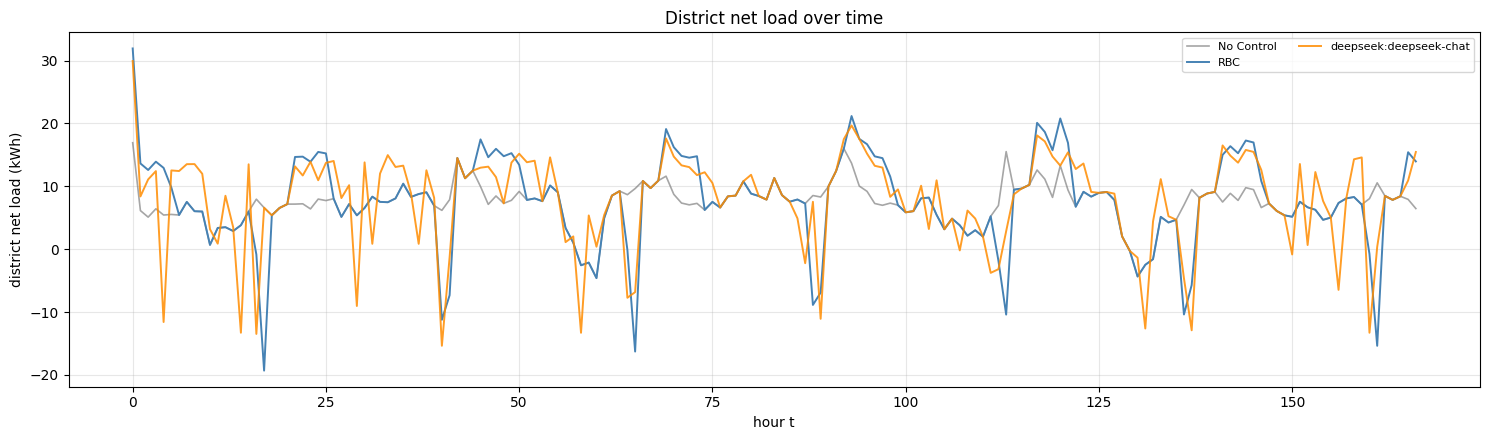

In [31]:
# 9.2 District net load over the week
fig, ax = plt.subplots(figsize=(15, 4.5))

ax.plot(
    df_noop["t"],
    df_noop[[f"net{i}" for i in range(6)]].sum(axis=1),
    label="No Control", lw=1.2, color="gray", alpha=0.7,
)
ax.plot(
    df_rbc["t"],
    df_rbc[[f"net{i}" for i in range(6)]].sum(axis=1),
    label="RBC", lw=1.4, color="steelblue",
)
colors = ["darkorange", "crimson", "forestgreen", "purple"]
for (name, run), color in zip(llm_runs.items(), colors):
    df_ = run["df"]
    ax.plot(
        df_["t"],
        df_[[f"net{i}" for i in range(6)]].sum(axis=1),
        label=run["label"], lw=1.4, color=color, alpha=0.85,
    )

ax.set_xlabel("hour t")
ax.set_ylabel("district net load (kWh)")
ax.set_title("District net load over time")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# 9.3 Behavioural summary per provider — sync rate, fallback rate, rule violations
def analyze_run(df: pd.DataFrame, raw_log: list[dict]) -> dict:
    n = len(df)
    A = df[[f"a{i}" for i in range(6)]].values
    signs = np.sign(A)

    sync_rate = float(np.all(signs == signs[:, [0]], axis=1).mean())
    fb_rate   = float(np.mean([r["fallback"] for r in raw_log])) if raw_log else 0.0

    SOC_post = df[[f"soc{i}" for i in range(6)]].values
    SOC_pre  = np.vstack([np.zeros(6), SOC_post[:-1]])
    charge_high   = int(((A > 0) & (SOC_pre >= 0.9)).sum())
    discharge_low = int(((A < 0) & (SOC_pre <= 0.1)).sum())

    return {
        "n_steps":          n,
        "sync_rate_pct":    round(sync_rate * 100, 1),
        "fallback_pct":     round(fb_rate * 100, 1),
        "charge_at_full":   charge_high,
        "discharge_at_empty": discharge_low,
        "mean_action":      round(float(A.mean()), 3),
        "std_action":       round(float(A.std()), 3),
    }


rows = []
for name, run in llm_runs.items():
    s = analyze_run(run["df"], run["raw_log"])
    s = {"provider": run["label"], **s}
    rows.append(s)

behaviour_df = pd.DataFrame(rows).set_index("provider")
print("Behavioural summary per provider:")
display(behaviour_df)
print(
    "\nLow sync_rate is GOOD (less likely to create demand spikes)."
    "\nfallback_pct = how often the response did not parse — should be ≈ 0."
    "\ncharge_at_full / discharge_at_empty = direct prompt-rule violations."
)

Behavioural summary per provider:


,n_steps,sync_rate_pct,fallback_pct,charge_at_full,discharge_at_empty,mean_action,std_action
provider,,,,,,,
deepseek:deepseek-chat,167,85.6,1.2,1,0,-0.021,0.33



Low sync_rate is GOOD (less likely to create demand spikes).
fallback_pct = how often the response did not parse — should be ≈ 0.
charge_at_full / discharge_at_empty = direct prompt-rule violations.


In [33]:
# 9.4 Action × price-regime crosstab per provider
def action_regime_table(df: pd.DataFrame) -> pd.DataFrame:
    A = df[[f"a{i}" for i in range(6)]].values
    direction = np.where(A >  0.05, "charge",
                  np.where(A < -0.05, "discharge", "idle"))
    regime = np.where(df["price"].values >= PRICE_PEAK_THRESHOLD, "PEAK", "LOW")
    regime_full = np.repeat(regime[:, None], 6, axis=1)
    ct = pd.crosstab(
        regime_full.ravel(), direction.ravel(),
        rownames=["price"], colnames=["action"],
        normalize="index",
    ) * 100
    for col in ("charge", "idle", "discharge"):
        if col not in ct.columns:
            ct[col] = 0.0
    return ct[["charge", "idle", "discharge"]].round(1)


for name, run in llm_runs.items():
    print(f"\n--- {run['label']} ---")
    print("  Ideal: LOW row → heavy 'charge', PEAK row → heavy 'discharge'")
    display(action_regime_table(run["df"]))


--- deepseek:deepseek-chat ---
  Ideal: LOW row → heavy 'charge', PEAK row → heavy 'discharge'


action,charge,idle,discharge
price,,,
LOW,56.1,31.3,12.6
PEAK,4.8,62.9,32.4


In [34]:
# 9.5 Inspect raw responses — same 2 timesteps from each provider for direct comparison
N_SHOW = 2

if not llm_runs:
    print("No LLM runs available.")
else:
    sample_log = next(iter(llm_runs.values()))["raw_log"]
    if not sample_log:
        print("No raw logs.")
    else:
        rng_diag = np.random.default_rng(SEED)
        n_show = min(N_SHOW, len(sample_log))
        picked = sorted(rng_diag.choice(len(sample_log), size=n_show, replace=False).tolist())

        for idx in picked:
            t = sample_log[idx]["t"]
            print("=" * 74)
            print(f"t={t}  STATE:")
            print("=" * 74)
            print(sample_log[idx]["state_text"])
            for name, run in llm_runs.items():
                entry = run["raw_log"][idx]
                print(f"\n--- {run['label']}  fallback={entry['fallback']} ---")
                print(entry["raw"])
            print()

t=14  STATE:
Month 12, Thu 14:00  |  price=0.210 (LOW)  |  carbon=0.207 (PEAK)  |  
Buildings:
  B0: SoC= 89.3%  load=3.43 kWh  last_net=+0.71 kWh  solar=HIGH
  B1: SoC= 95.3%  load=0.78 kWh  last_net=+1.04 kWh  solar=HIGH
  B2: SoC= 88.9%  load=0.31 kWh  last_net=+0.48 kWh  solar=HIGH
  B3: SoC= 89.5%  load=0.59 kWh  last_net=+0.46 kWh  solar=HIGH
  B4: SoC= 94.9%  load=1.05 kWh  last_net=+0.14 kWh  solar=HIGH
  B5: SoC= 89.2%  load=1.95 kWh  last_net=+0.67 kWh  solar=HIGH

--- deepseek:deepseek-chat  fallback=False ---
Step 1: Price is LOW (0.210), so charging is cheap. Carbon is PEAK (0.207), meaning discharging now reduces carbon impact. Solar is HIGH for all buildings, meaning free PV available.

Step 2: Charge room:
- B0: 1 - 0.893 = 0.107 (10.7% headroom)
- B1: 1 - 0.953 = 0.047 (4.7% headroom)
- B2: 1 - 0.889 = 0.111 (11.1% headroom)
- B3: 1 - 0.895 = 0.105 (10.5% headroom)
- B4: 1 - 0.949 = 0.051 (5.1% headroom)
- B5: 1 - 0.892 = 0.108 (10.8% headroom)

Discharge room:
- B0: 0

## 10. Save Artifacts

In [ ]:
artifacts = Path("artifacts")
artifacts.mkdir(exist_ok=True)
stamp = time.strftime("%Y%m%d_%H%M%S")

all_dfs = [df_noop, df_random, df_rbc] + [r["df"] for r in llm_runs.values()]
df_all = pd.concat(all_dfs, ignore_index=True)
csv_path = artifacts / f"llm_multi_provider_{stamp}.csv"
df_all.to_csv(csv_path, index=False)
print(f"Rollout data saved: {csv_path}")

if present:
    kpi_path = artifacts / f"kpi_multi_provider_{stamp}.csv"
    kpi_table.loc[present].to_csv(kpi_path)
    print(f"KPI table saved:    {kpi_path}")

if not behaviour_df.empty:
    bh_path = artifacts / f"behaviour_multi_provider_{stamp}.csv"
    behaviour_df.to_csv(bh_path)
    print(f"Behaviour summary:  {bh_path}")